Importing libraries and loading the dataset

In [29]:
import numpy as np
import pandas as pd

attrition_df = pd.read_csv('hr_attrition_dataset.csv')

Drop duplicates and check data info

In [30]:
attrition_df = attrition_df.drop_duplicates()
attrition_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employee_id                  15000 non-null  str    
 1   age                          15000 non-null  int64  
 2   gender                       15000 non-null  str    
 3   marital_status               15000 non-null  str    
 4   education                    15000 non-null  str    
 5   education_field              15000 non-null  str    
 6   num_companies_worked         15000 non-null  int64  
 7   department                   15000 non-null  str    
 8   job_role                     15000 non-null  str    
 9   job_level                    15000 non-null  int64  
 10  employment_type              15000 non-null  str    
 11  years_at_company             15000 non-null  int64  
 12  years_in_current_role        15000 non-null  int64  
 13  total_working_years        

Data Type Casting for Performance Rating and Job Satisfaction

In [31]:
for col in ['job_satisfaction', 'performance_rating']:
    attrition_df[col] = attrition_df[col].round()

Null value imputation for performance_rating based on Department, Job Role, Job Level, Employment Type, Manager Rating, Skills Growth Opportunities

In [32]:
rating_hierarchy = [
    ['department', 'job_role', 'job_level', 'employment_type', 'manager_rating', 'skills_growth_opportunities'],
    ['department', 'job_role', 'job_level', 'employment_type', 'manager_rating'],
]

for group_cols in rating_hierarchy:
    attrition_df['performance_rating'] = attrition_df['performance_rating'].fillna(
        attrition_df.groupby(group_cols)['performance_rating'].transform('mean')
    )

attrition_df['performance_rating'] = attrition_df['performance_rating'].fillna(attrition_df['manager_rating'])

Null value imputation for Monthly Income Based on Department, Job Role, Job Level, Employment Type

In [33]:
group_cols_monthly_income = ['department', 'job_role','job_level','employment_type']

attrition_df['monthly_income'] = attrition_df['monthly_income'].fillna(
    attrition_df.groupby(group_cols_monthly_income)['monthly_income'].transform('mean')
)

Null value imputation for job satisfaction based on Department, Job Role, Job Level, Employment Type, Work Life Balance

In [34]:

import numpy as np
import math

def custom_round(x):
    if pd.isna(x):
        return np.nan           
    decimal = x - math.floor(x)
    if decimal < 0.5:
        return math.floor(x)
    else:
        return math.ceil(x)


attrition_df['job_satisfaction'] = attrition_df['job_satisfaction'].apply(custom_round)

group_cols_job_satisfaction = ['department', 'job_role','job_level','employment_type','work_life_balance']
attrition_df['job_satisfaction'] = attrition_df['job_satisfaction'].fillna(
    attrition_df.groupby(group_cols_job_satisfaction)['job_satisfaction'].transform('mean').round(2)
)
attrition_df['job_satisfaction'] = attrition_df['job_satisfaction'].fillna(attrition_df['work_life_balance']).round(2)

attrition_df['job_satisfaction']  = attrition_df['job_satisfaction'].apply(custom_round)

Creation of age groups based on categories: Gen Z, Early Career, Mid-Career, Experienced, Late Career

In [35]:
bins = [21, 25, 35, 45, 55, 65]
labels = ['Fresher', 'Early-Career', 'Mid-Career', 'Experienced', 'Late-Career']

attrition_df['age_group'] = pd.cut(attrition_df['age'], bins=bins, labels=labels)

Creation of Average Tenure per Company based on Total Working Years and Number of Companies Worked

In [36]:
attrition_df['avg_tenure_per_company'] = (
    attrition_df['total_working_years'] / attrition_df['num_companies_worked'].replace(0, 1)
)
attrition_df['avg_tenure_per_company'] = attrition_df['avg_tenure_per_company'].round(2)

Creation of Role Stagnation Ratio based on Years in Current Role and Years at Company

In [37]:
attrition_df['role_stagnation_ratio'] = (
    attrition_df['years_in_current_role'] / attrition_df['years_at_company'].replace(0, 1)
)

attrition_df['role_stagnation_ratio'] = attrition_df['role_stagnation_ratio'].round(2)

Creation of Promotion Velocity based on Years at Company and Promotions in Last 5 Years

In [38]:
attrition_df['promotion_velocity'] = (
    attrition_df['years_at_company'] / (attrition_df['promotions_last_5years'])
).round(2)
attrition_df['promotion_velocity'] = attrition_df['promotion_velocity'].replace([np.inf, np.nan], 0)

Creation of Total Overtime Hours based on Overtime Hours per Week and Years in Current Role

In [39]:
attrition_df['total_overtime_hours'] = (
    attrition_df['overtime_hours_per_week'] * attrition_df['years_in_current_role'] * 52
)


Creation of Overtime Category based on Total Overtime hours

In [40]:
def calculate_overtime_category(row):
    if row['total_overtime_hours'] > 4000:
        return 'High-Overwork'
    elif row['total_overtime_hours'] > 1000 and row['total_overtime_hours'] <= 4000:
        return 'Medium-Overwork'
    else:
        return 'Low-Overwork'
    

attrition_df['overtime_category'] = attrition_df.apply(calculate_overtime_category, axis=1)

Creation of Burnout Risk Score based on Overtime Hours per week, Overtime Paid Eligible

In [41]:
high_ot_threshold = 10

attrition_df['burnout_risk_flag'] = (
    (attrition_df['overtime_hours_per_week'] > high_ot_threshold) & 
    (attrition_df['overtime_paid_eligible'] == 'No')
)

Creation of Income group based on Monthly Income 

In [42]:

attrition_df['income_group'] = pd.cut(attrition_df['monthly_income'], bins=3, labels=['Low-Income', 'Medium-Income', 'High-Income'])
display(attrition_df.head())

,employee_id,age,gender,marital_status,education,education_field,num_companies_worked,department,job_role,job_level,...,remote_work_days_per_week,attrition,age_group,avg_tenure_per_company,role_stagnation_ratio,promotion_velocity,total_overtime_hours,overtime_category,burnout_risk_flag,income_group
0,EMP_00000001,35,Male,Married,Bachelor,Business,1,IT,Junior,4,...,2,Yes,Early-Career,4.00,1.00,1.0,2652,Medium-Overwork,True,Medium-Income
1,EMP_00000002,44,Male,Divorced,Bachelor,Arts,1,Sales,Junior,2,...,2,Yes,Mid-Career,6.00,0.67,0.0,416,Low-Overwork,False,Low-Income
2,EMP_00000003,38,Female,Single,Bachelor,Business,3,Finance,Senior,5,...,0,No,Mid-Career,6.33,3.00,0.0,156,Low-Overwork,False,Low-Income
3,EMP_00000004,40,Male,Single,Master,Business,5,Sales,Junior,3,...,1,No,Mid-Career,0.80,3.00,0.0,1560,Medium-Overwork,False,Low-Income
4,EMP_00000005,32,Male,Single,Master,Technical,1,Sales,Junior,3,...,0,No,Early-Career,3.00,1.50,0.0,156,Low-Overwork,False,Low-Income


Creation of Income Age Group by combining Income Group and Age Group

In [43]:
attrition_df['income_age_group'] = (
    attrition_df['income_group'].astype(str) + '_' + attrition_df['age_group'].astype(str)
)

Creation of income per year of experience by dividing Monthly Income by Total Working Years 

In [44]:
safe_experience_years = attrition_df['total_working_years'].replace(0, 1)
attrition_df['income_per_year_experience'] = (
    attrition_df['monthly_income'] / safe_experience_years
).round(2)

Creation of Commute Strain by combining Distance from Home and Remote Work Days per Week

In [45]:
attrition_df['commute_strain'] = (
    attrition_df['distance_from_home_km'] * (5 - attrition_df['remote_work_days_per_week'])
).round(2)


Creation of Hike Performance Gap by comparing Percent Salary Hike and Performance Rating

In [46]:
attrition_df['hike_performance_gap'] = (
    attrition_df['percent_salary_hike'] - attrition_df['performance_rating']
).round(2)

Creation of Manager Satisfaction by combining Manager Rating and Job Satisfaction

In [47]:
attrition_df['manager_satisfaction_delta'] = (
    attrition_df['manager_rating'] - attrition_df['job_satisfaction']
).round(2)

### Setup Cell

Prepare reusable imports, helper functions, and safe defaults for all following cells.

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, chi2_contingency, ttest_ind

alpha = 0.05

attrition_df = attrition_df.copy()
attrition_df['attrition_flag'] = (attrition_df['attrition'] == 'Yes').astype(int)

if 'age_group' not in attrition_df.columns:
    age_bins = [21, 25, 35, 45, 55, 65]
    age_labels = ['Fresher', 'Early-Career', 'Mid-Career', 'Experienced', 'Late-Career']
    attrition_df['age_group'] = pd.cut(attrition_df['age'], bins=age_bins, labels=age_labels)

def conclude(p_value, alpha=0.05):
    return 'Reject H0 (statistically significant)' if p_value < alpha else 'Fail to reject H0 (not statistically significant)'

def skew_label(v):
    if v > 0.3:
        return 'Right-skewed'
    if v < -0.3:
        return 'Left-skewed'
    return 'Approximately symmetric'

hypothesis_results = []

### EDA 1: Heatmap (Department x Job Level Attrition Rate)

Purpose: identify combinations of department and level where attrition risk is structurally high.

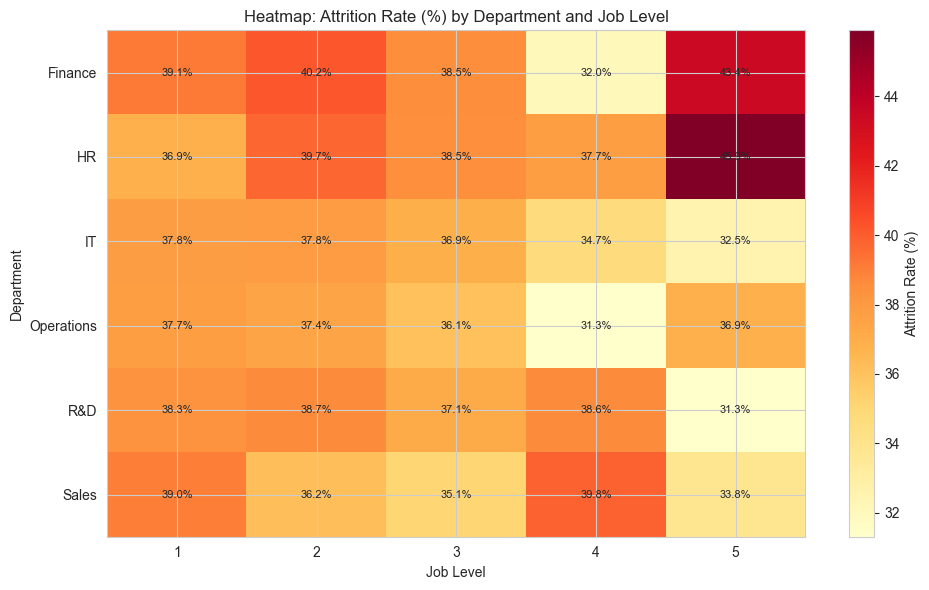

In [49]:
heat_data = (
    attrition_df
    .groupby(['department', 'job_level'])['attrition_flag']
    .mean()
    .mul(100)
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heat_data.values, cmap='YlOrRd', aspect='auto')
ax.set_title('Heatmap: Attrition Rate (%) by Department and Job Level')
ax.set_xlabel('Job Level')
ax.set_ylabel('Department')
ax.set_xticks(np.arange(len(heat_data.columns)))
ax.set_xticklabels(heat_data.columns)
ax.set_yticks(np.arange(len(heat_data.index)))
ax.set_yticklabels(heat_data.index)

for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        ax.text(j, i, f"{heat_data.iloc[i, j]:.1f}%", ha='center', va='center', fontsize=8)

fig.colorbar(im, ax=ax, label='Attrition Rate (%)')
plt.tight_layout()
plt.show()

### EDA 2: Scatter Plot (Income vs Overtime)

Purpose: compare workload and compensation across department-level clusters, while coloring by attrition risk.

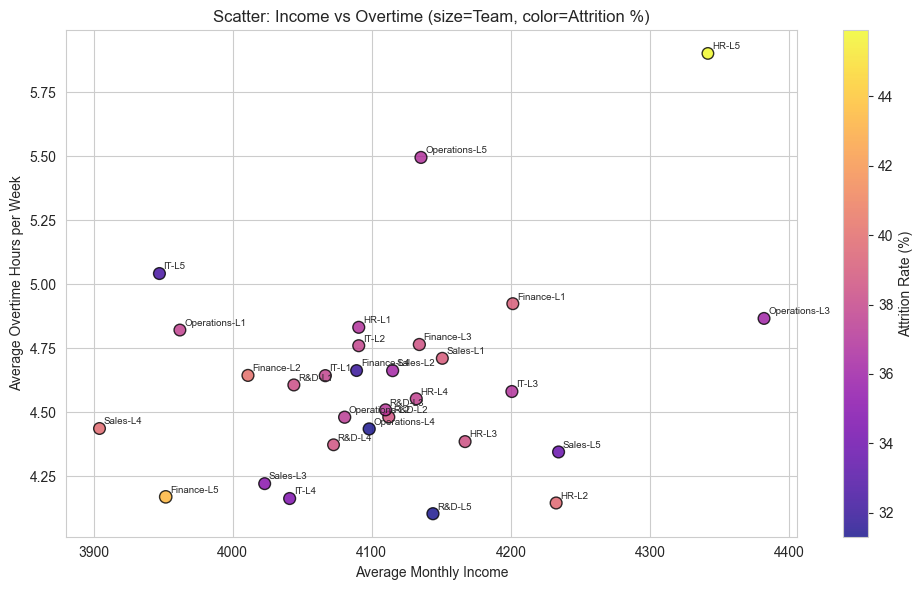

In [50]:
scatter_data = (
    attrition_df
    .groupby(['department', 'job_level'])
    .agg(
        avg_income=('monthly_income', 'mean'),
        avg_overtime=('overtime_hours_per_week', 'mean'),
        avg_team_size=('team_size', 'mean'),
        attrition_rate=('attrition_flag', 'mean')
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sizes = scatter_data['avg_team_size'] * 12
colors = scatter_data['attrition_rate'] * 100
sc = ax.scatter(
    scatter_data['avg_income'],
    scatter_data['avg_overtime'],
    s=sizes,
    c=colors,
    cmap='plasma',
    alpha=0.8,
    edgecolors='black'
)

for _, row in scatter_data.iterrows():
    ax.annotate(
        f"{row['department']}-L{int(row['job_level'])}",
        (row['avg_income'], row['avg_overtime']),
        fontsize=7,
        xytext=(3, 3),
        textcoords='offset points'
    )

ax.set_title('Scatter: Income vs Overtime (size=Team, color=Attrition %)')
ax.set_xlabel('Average Monthly Income')
ax.set_ylabel('Average Overtime Hours per Week')
fig.colorbar(sc, ax=ax, label='Attrition Rate (%)')
plt.tight_layout()
plt.show()

### EDA 3: Stacked Bar Chart (Department + Age Group + Attrition)

Purpose: compare demographic composition inside attrition Yes vs No, department by department.

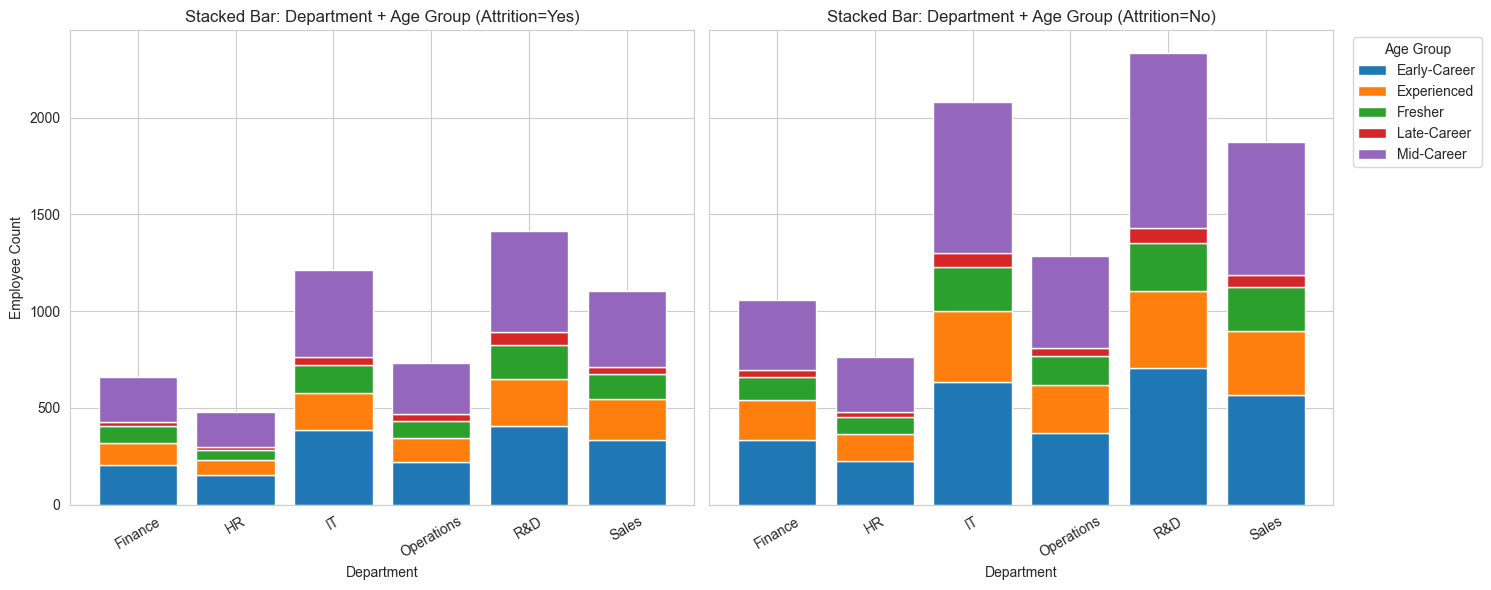

In [51]:
bar_data = (
    attrition_df
    .groupby(['department', 'age_group', 'attrition'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
bar_data['age_group'] = bar_data['age_group'].astype(str)

departments = sorted(bar_data['department'].unique())
age_groups = sorted(bar_data['age_group'].unique())

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for idx, status in enumerate(['Yes', 'No']):
    pivot = bar_data.pivot_table(index='department', columns='age_group', values=status, fill_value=0)
    pivot = pivot.reindex(index=departments, columns=age_groups, fill_value=0)
    bottom = np.zeros(len(pivot.index))

    for age in pivot.columns:
        axes[idx].bar(pivot.index, pivot[age].values, bottom=bottom, label=age)
        bottom += pivot[age].values

    axes[idx].set_title(f'Stacked Bar: Department + Age Group (Attrition={status})')
    axes[idx].set_xlabel('Department')
    axes[idx].tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Employee Count')
axes[1].legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### EDA 4: Line Chart (Tenure Bucket Trend)

Purpose: observe how attrition changes with years at company across top-risk departments.

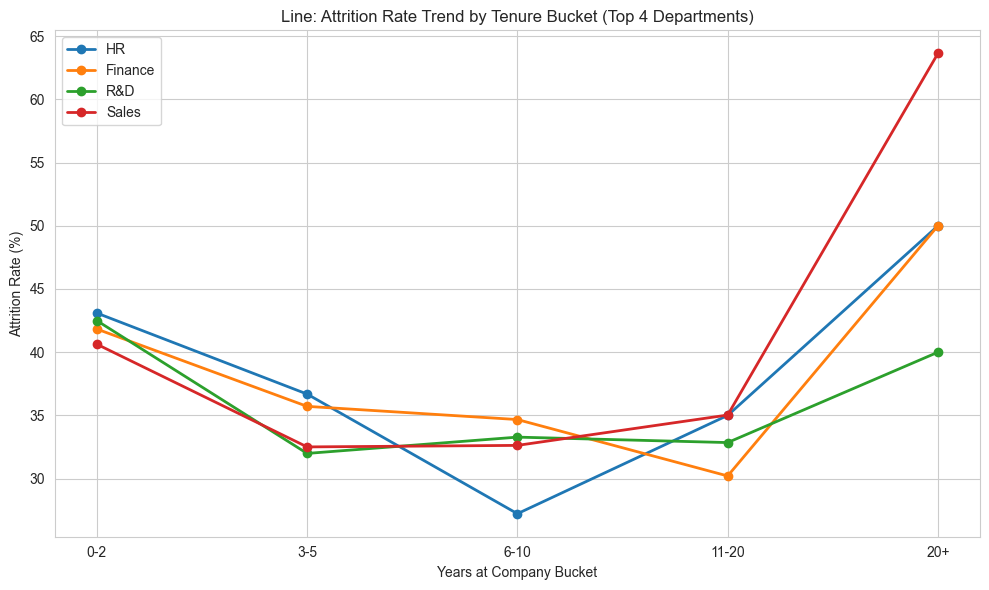

In [52]:
attrition_df['tenure_bucket'] = pd.cut(
    attrition_df['years_at_company'],
    bins=[0, 2, 5, 10, 20, 40],
    labels=['0-2', '3-5', '6-10', '11-20', '20+'],
    include_lowest=True
)

line_data = (
    attrition_df
    .groupby(['tenure_bucket', 'department'])['attrition_flag']
    .mean()
    .mul(100)
    .reset_index()
)

top_departments = (
    attrition_df.groupby('department')['attrition_flag']
    .mean()
    .sort_values(ascending=False)
    .head(4)
    .index
)

fig, ax = plt.subplots(figsize=(10, 6))
for dept in top_departments:
    dept_data = line_data[line_data['department'] == dept]
    ax.plot(
        dept_data['tenure_bucket'].astype(str),
        dept_data['attrition_flag'],
        marker='o',
        linewidth=2,
        label=dept
    )

ax.set_title('Line: Attrition Rate Trend by Tenure Bucket (Top 4 Departments)')
ax.set_xlabel('Years at Company Bucket')
ax.set_ylabel('Attrition Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

### EDA 5: Pie Chart (Attrition Contribution by Department)

Purpose: show which departments contribute the largest share of attrition exits.

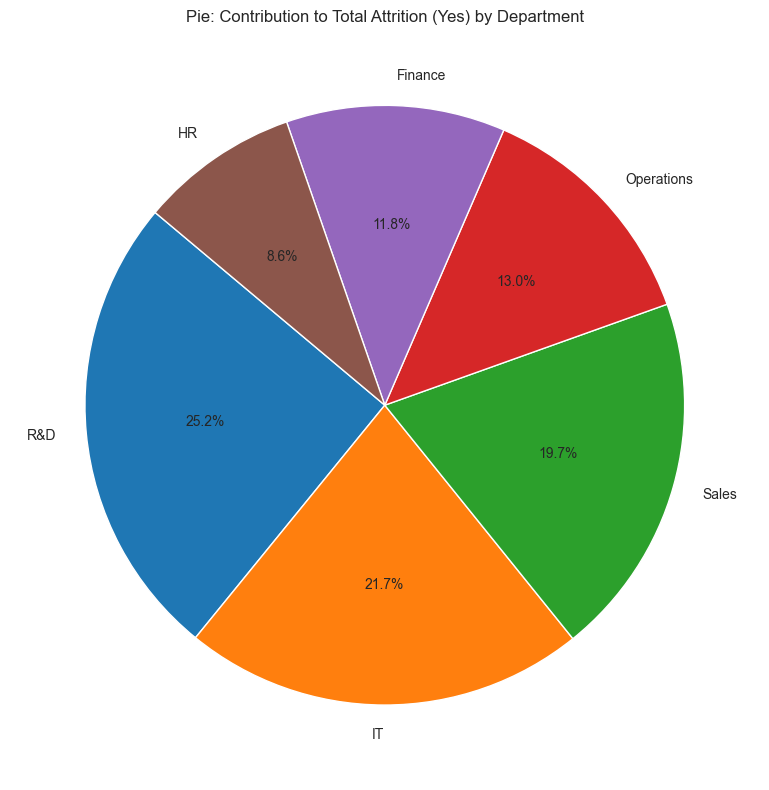

In [53]:
pie_data = (
    attrition_df[attrition_df['attrition'] == 'Yes']
    .groupby('department')
    .size()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white'}
)
ax.set_title('Pie: Contribution to Total Attrition (Yes) by Department')
plt.tight_layout()
plt.show()

### EDA 6: Box Chart (Commute Strain by Travel Type and Attrition)

Purpose: compare commute-stress spread by travel policy for retained vs resigned employees.

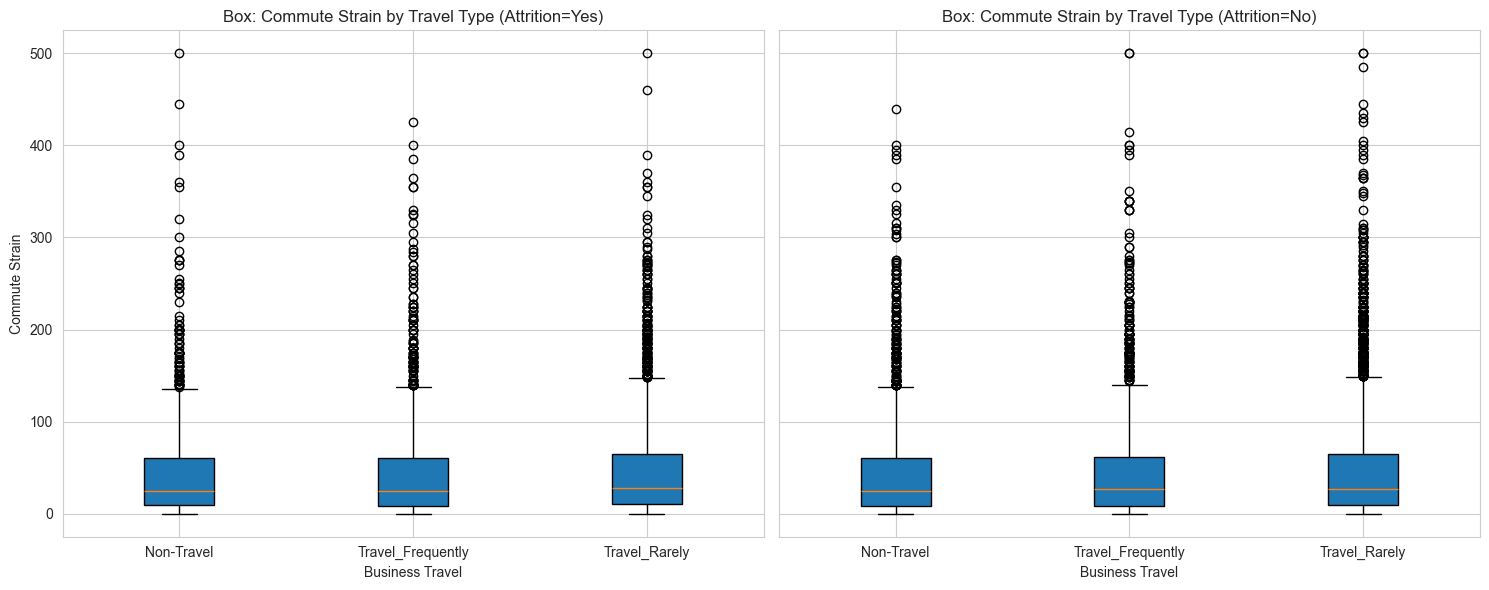

In [54]:
travel_levels = sorted(attrition_df['business_travel'].dropna().unique())
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for idx, status in enumerate(['Yes', 'No']):
    subset = attrition_df[attrition_df['attrition'] == status]
    box_values = [subset[subset['business_travel'] == t]['commute_strain'].dropna() for t in travel_levels]
    axes[idx].boxplot(box_values, tick_labels=travel_levels, patch_artist=True)
    axes[idx].set_title(f'Box: Commute Strain by Travel Type (Attrition={status})')
    axes[idx].set_xlabel('Business Travel')

axes[0].set_ylabel('Commute Strain')
plt.tight_layout()
plt.show()

### EDA 7: Histogram with Skewness Interpretation

Purpose: detect distribution shape and explicitly classify right-skew and left-skew patterns.

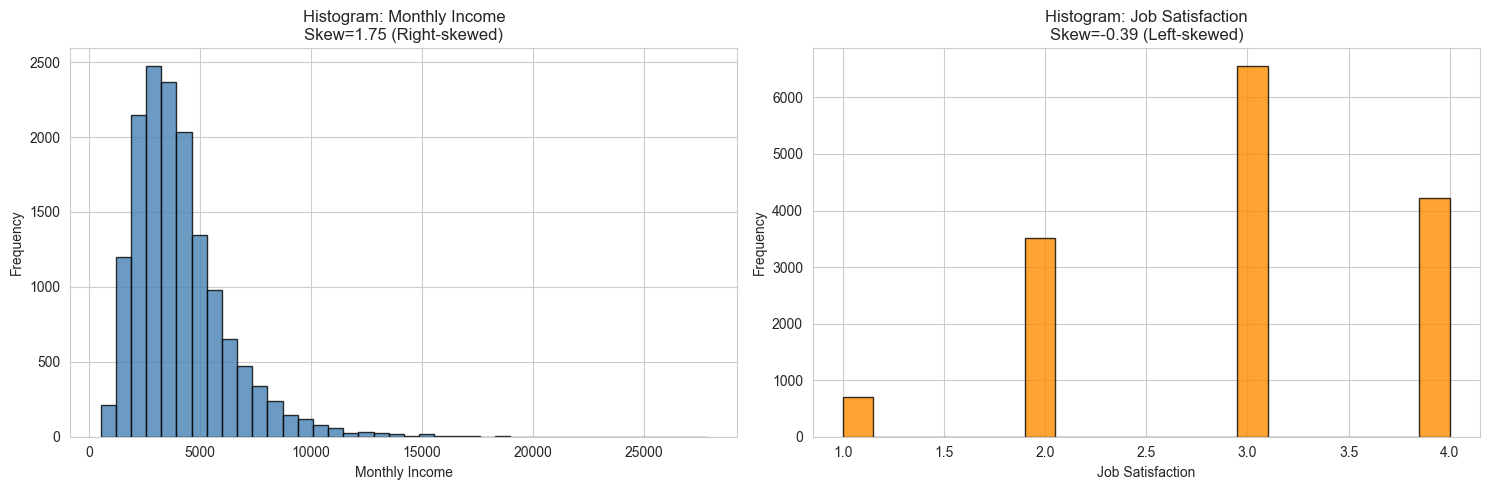

Monthly Income -> 1.755 (Right-skewed)
Job Satisfaction -> -0.392 (Left-skewed)


In [55]:
income_skew = skew(attrition_df['monthly_income'].dropna())
satisfaction_skew = skew(attrition_df['job_satisfaction'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(attrition_df['monthly_income'].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title(f"Histogram: Monthly Income\nSkew={income_skew:.2f} ({skew_label(income_skew)})")
axes[0].set_xlabel('Monthly Income')
axes[0].set_ylabel('Frequency')

axes[1].hist(attrition_df['job_satisfaction'].dropna(), bins=20, color='darkorange', edgecolor='black', alpha=0.8)
axes[1].set_title(f"Histogram: Job Satisfaction\nSkew={satisfaction_skew:.2f} ({skew_label(satisfaction_skew)})")
axes[1].set_xlabel('Job Satisfaction')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Monthly Income -> {income_skew:.3f} ({skew_label(income_skew)})")
print(f"Job Satisfaction -> {satisfaction_skew:.3f} ({skew_label(satisfaction_skew)})")

### Hypothesis 1: Hike Performance Gap vs Attrition (Welch t-test)

H0: Mean hike_performance_gap is the same for Attrition Yes and No.

In [56]:
h1_yes = attrition_df.loc[attrition_df['attrition'] == 'Yes', 'hike_performance_gap'].dropna()
h1_no = attrition_df.loc[attrition_df['attrition'] == 'No', 'hike_performance_gap'].dropna()

t_h1, p_h1 = ttest_ind(h1_yes, h1_no, equal_var=False)
print('H1 statistic:', round(t_h1, 4), '| p-value:', round(p_h1, 6))
print('Decision:', conclude(p_h1, alpha))

hypothesis_results.append({
    'hypothesis': 'H1: Hike Performance Gap vs Attrition',
    'p_value': p_h1,
    'decision': conclude(p_h1, alpha)
})

H1 statistic: 1.129 | p-value: 0.258928
Decision: Fail to reject H0 (not statistically significant)


### Hypothesis 2: Manager Satisfaction Delta vs Attrition (Welch t-test)

H0: Mean manager_satisfaction_delta is the same for Attrition Yes and No.

In [57]:
h2_yes = attrition_df.loc[attrition_df['attrition'] == 'Yes', 'manager_satisfaction_delta'].dropna()
h2_no = attrition_df.loc[attrition_df['attrition'] == 'No', 'manager_satisfaction_delta'].dropna()

t_h2, p_h2 = ttest_ind(h2_yes, h2_no, equal_var=False)
print('H2 statistic:', round(t_h2, 4), '| p-value:', round(p_h2, 6))
print('Decision:', conclude(p_h2, alpha))

hypothesis_results.append({
    'hypothesis': 'H2: Manager Satisfaction Delta vs Attrition',
    'p_value': p_h2,
    'decision': conclude(p_h2, alpha)
})

H2 statistic: 16.5154 | p-value: 0.0
Decision: Reject H0 (statistically significant)


### Hypothesis 3: Years Since Last Promotion vs Attrition (Welch t-test)

H0: Mean years_since_last_promotion is the same for Attrition Yes and No.

In [58]:
h3_yes = attrition_df.loc[attrition_df['attrition'] == 'Yes', 'years_since_last_promotion'].dropna()
h3_no = attrition_df.loc[attrition_df['attrition'] == 'No', 'years_since_last_promotion'].dropna()

t_h3, p_h3 = ttest_ind(h3_yes, h3_no, equal_var=False)
print('H3 statistic:', round(t_h3, 4), '| p-value:', round(p_h3, 6))
print('Decision:', conclude(p_h3, alpha))

hypothesis_results.append({
    'hypothesis': 'H3: Years Since Last Promotion vs Attrition',
    'p_value': p_h3,
    'decision': conclude(p_h3, alpha)
})

H3 statistic: 12.2345 | p-value: 0.0
Decision: Reject H0 (statistically significant)


### Hypothesis 4: Business Travel vs Attrition (Chi-square)

H0: business_travel and attrition are independent.

In [59]:
cont_h4 = pd.crosstab(attrition_df['business_travel'], attrition_df['attrition'])
chi_h4, p_h4, dof_h4, exp_h4 = chi2_contingency(cont_h4)

print('H4 statistic:', round(chi_h4, 4), '| p-value:', round(p_h4, 6), '| dof:', dof_h4)
print('Decision:', conclude(p_h4, alpha))

hypothesis_results.append({
    'hypothesis': 'H4: Business Travel vs Attrition',
    'p_value': p_h4,
    'decision': conclude(p_h4, alpha)
})

H4 statistic: 80.8717 | p-value: 0.0 | dof: 2
Decision: Reject H0 (statistically significant)


### Hypothesis 5: Department vs Attrition (Chi-square)

H0: department and attrition are independent.

In [60]:
cont_h5 = pd.crosstab(attrition_df['department'], attrition_df['attrition'])
chi_h5, p_h5, dof_h5, exp_h5 = chi2_contingency(cont_h5)

print('H5 statistic:', round(chi_h5, 4), '| p-value:', round(p_h5, 6), '| dof:', dof_h5)
print('Decision:', conclude(p_h5, alpha))

hypothesis_results.append({
    'hypothesis': 'H5: Department vs Attrition',
    'p_value': p_h5,
    'decision': conclude(p_h5, alpha)
})

H5 statistic: 3.6899 | p-value: 0.59486 | dof: 5
Decision: Fail to reject H0 (not statistically significant)


### Hypothesis Summary Table

Purpose: collect all five tests in one business-readable decision table.

In [61]:
summary_table = pd.DataFrame(hypothesis_results)
summary_table

,hypothesis,p_value,decision
0,H1: Hike Performance Gap vs Attrition,2.589281e-01,Fail to reject H0 (not statistically significant)
1,H2: Manager Satisfaction Delta vs Attrition,1.489660e-60,Reject H0 (statistically significant)
2,H3: Years Since Last Promotion vs Attrition,3.569222e-34,Reject H0 (statistically significant)
3,H4: Business Travel vs Attrition,2.747523e-18,Reject H0 (statistically significant)
4,H5: Department vs Attrition,5.948605e-01,Fail to reject H0 (not statistically significant)
